# 07: Pointcloud Labeling from Frame Segmentation

This notebook demonstrates how to transfer 2D segmentation results to a 3D pointcloud, using data from Project Aria. The goal is to assign semantic labels to each 3D point by projecting it onto the segmented image and reading the corresponding label.

### In this notebook, we will:
1. Load MPS data: pointcloud and camera trajectory.
2. Synchronize each segmented frame with the closest camera pose.
3. For each 3D point:
    - Transform from world to camera coordinates.
    - Project onto the image plane.
    - Assign a label from the segmentation mask at the projected pixel.
4. Visualize the labeled pointcloud.

As a sample, we will use `kettle_and_forklift_recording.vrs` located in the local `data/raw/kettle_and_forklift/` directory and its corresponding segmentation masks located in `data/outputs/segmentation/kettle_and_forklift/sam2/masks` .

### Note:
This approach will also label points behind the object ("tunnel effect"), but is a robust first step for 2D/3D semantic bridging.

## 7.1 Load MPS Pointcloud and Camera Trajectory


In this section, we load the 3D pointcloud and the camera trajectory (poses) produced by MPS.

- The pointcloud is typically stored as `semidense_points.csv` or `semidense_points.csv.gz` and contains $(X, Y, Z)$ coordinates for each point.
- The trajectory is stored as `closed_loop_trajectory.csv` and contains timestamped camera poses (position + orientation).

In [4]:
import os
import pandas as pd
from aria_pylib import find_points_file, find_trajectory_file

# Define the directory containing MPS outputs
MPS_DIR = os.path.join('..', 'data', 'raw', 'kettle_and_forklift', 'mps_kettle_and_forklift_recording_vrs', 'slam')

# Load the pointcloud file
points_path = find_points_file(MPS_DIR)
print(f"Loading pointcloud from: {points_path}")
points_df = pd.read_csv(points_path)

# Load trajectory file
trajectory_path = find_trajectory_file(MPS_DIR)
print(f"Loading trajectory from: {trajectory_path}")
trajectory_df = pd.read_csv(trajectory_path)
print(f"Loaded {len(trajectory_df)} poses.")


Loading pointcloud from: ..\data\raw\kettle_and_forklift\mps_kettle_and_forklift_recording_vrs\slam\semidense_points.csv.gz
Loading trajectory from: ..\data\raw\kettle_and_forklift\mps_kettle_and_forklift_recording_vrs\slam\closed_loop_trajectory.csv
Loaded 50626 poses.


## 7.2 Synchronize trajectory and pointcloud timestamps
Now that we have loaded both the pointcloud and the trajectory, we need to synchronize their timestamps. This step ensures that each 3D point can be associated with the correct camera pose for projection into the image frame.

In [5]:
# For each point it finds the closest pose in time from the trajectory
# The pointcloud and trajectory share the 'graph_uid' column, which can be used to join them.
trajectory_unique = trajectory_df.drop_duplicates('graph_uid')
points_synced = pd.merge(points_df, trajectory_unique, on='graph_uid', how='left', suffixes=('', '_pose'))
print(f"Synchronized {len(points_synced)} points with unique 'graph_uid' poses.")

Synchronized 239524 points with unique 'graph_uid' poses.


## 7.3 Project 3D points onto the image plane
We will now project each 3D point in world coordinates onto the image plane using the corresponding camera pose and intrinsics. This will allow us to find the pixel location for each point and later assign a segmentation label.

### 7.3.1 Transform from world to camera coordinates
For each 3D point, we will apply the inverse of the camera pose to transform it from world coordinates to camera coordinates.

In [6]:
import os
import cv2
import numpy as np
from projectaria_tools.core import data_provider

# load vrs and masks path
vrs_path = os.path.join('..', 'data', 'raw', 'kettle_and_forklift', 'kettle_and_forklift_recording.vrs')
masks_dir = os.path.join('..', 'data', 'outputs', 'segmentation', 'kettle_and_forklift', 'sam2', 'masks')
frame_idx = 50 # good frame for visualization

# load calibration from vrs and compute the transform from device to camera
provider = data_provider.create_vrs_data_provider(vrs_path)
device_calib = provider.get_device_calibration()
rgb_calib = device_calib.get_camera_calib("camera-rgb")
T_Device_Camera = rgb_calib.get_transform_device_camera()

# upload the mask for the selected frame
mask_filename = f"{frame_idx:06d}.png"
mask_path = os.path.join(masks_dir, mask_filename)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

if mask is None:
    raise FileNotFoundError(f"Could not load mask at {mask_path}. Check if the file exists!")
else:
    print(f"Setup complete. Mask shape: {mask.shape}")
    print(f"Unique values in mask: {np.unique(mask)}") # 0 for background, other values for objects

Setup complete. Mask shape: (1408, 1408)
Unique values in mask: [0 1 2]


### 7.3.2 Project from camera coordinates to pixel coordinates
Once we have the point in camera coordinates, we will apply the camera intrinsics to project it onto the 2D image plane, obtaining pixel coordinates.

In [7]:
from scipy.spatial.transform import Rotation as R

def project_world_to_rgb_image(point_world, pose_row, rgb_calib, T_Device_Camera):
    """
    Projects a 3D point from world coordinates to RGB pixel coordinates.
    Handles T_World_Device (MPS), T_Device_Camera (Extrinsics), and Distortion (Intrinsics).
    """
    # World to Device
    quat = [pose_row['qx_world_device'], pose_row['qy_world_device'], 
            pose_row['qz_world_device'], pose_row['qw_world_device']]
    rot_world_device = R.from_quat(quat).as_matrix()
    t_world_device = np.array([pose_row['tx_world_device'], 
                               pose_row['ty_world_device'], 
                               pose_row['tz_world_device']])
    
    # P_device = R_world_device^T * (P_world - t_world_device)
    point_device = rot_world_device.T @ (point_world - t_world_device)
    
    # Device to Camera RGB
    T_Camera_Device = T_Device_Camera.inverse()
    point_cam = T_Camera_Device @ point_device
    
    # Camera to Pixel
    pixel = rgb_calib.project(point_cam)
    
    return pixel

### 7.3.3 Assign semantic labels from the segmentation mask
With the pixel coordinates, we will read the corresponding value from the segmentation mask. This value will be assigned as the semantic label for the 3D point. If the pixel falls outside the image bounds, we will assign a default label (background).

In [8]:
from tqdm import tqdm

def label_pointcloud_multiclass(points_df, rgb_calib, T_Device_Camera, mask):
    """
    Iterates through the pointcloud and assigns labels from the 2D mask.
    """
    labels = []
    points_df_copy = points_df.copy()
    
    print(f"Projecting {len(points_df_copy)} points onto Frame {frame_idx}...")
    for idx, row in tqdm(points_df_copy.iterrows(), total=len(points_df_copy)):
        point_3d = np.array([row['px_world'], row['py_world'], row['pz_world']])
        
        pixel = project_world_to_rgb_image(point_3d, row, rgb_calib, T_Device_Camera)
        
        label = 0 # Background
        if pixel is not None:
            u, v = int(round(pixel[0])), int(round(pixel[1]))
            if 0 <= v < mask.shape[0] and 0 <= u < mask.shape[1]:
                label = mask[v, u]
        
        labels.append(label)
    
    points_df_copy['semantic_label'] = labels
    return points_df_copy

# Execute labeling
labeled_points = label_pointcloud_multiclass(points_synced, rgb_calib, T_Device_Camera, mask)

# Verify distinct labels found
unique_labels = np.unique(labeled_points['semantic_label'])
print(f"Found unique labels in 3D: {unique_labels}")

Projecting 239524 points onto Frame 50...


100%|██████████| 239524/239524 [00:17<00:00, 13803.70it/s]

Found unique labels in 3D: [0 1 2]


## 7.4 Visualize the labeled pointcloud
We will now visualize the 3D pointcloud with colors corresponding to the assigned semantic labels, and optionally overlay the projected points on the original image for verification.

### 7.4.1 Visualize in 2D with segmentation overlay
We will create a 2D visualization where the projected points are overlaid on the original image, colored by their assigned labels.

Detected Object IDs in 3D: [np.uint64(1), np.uint64(2)]


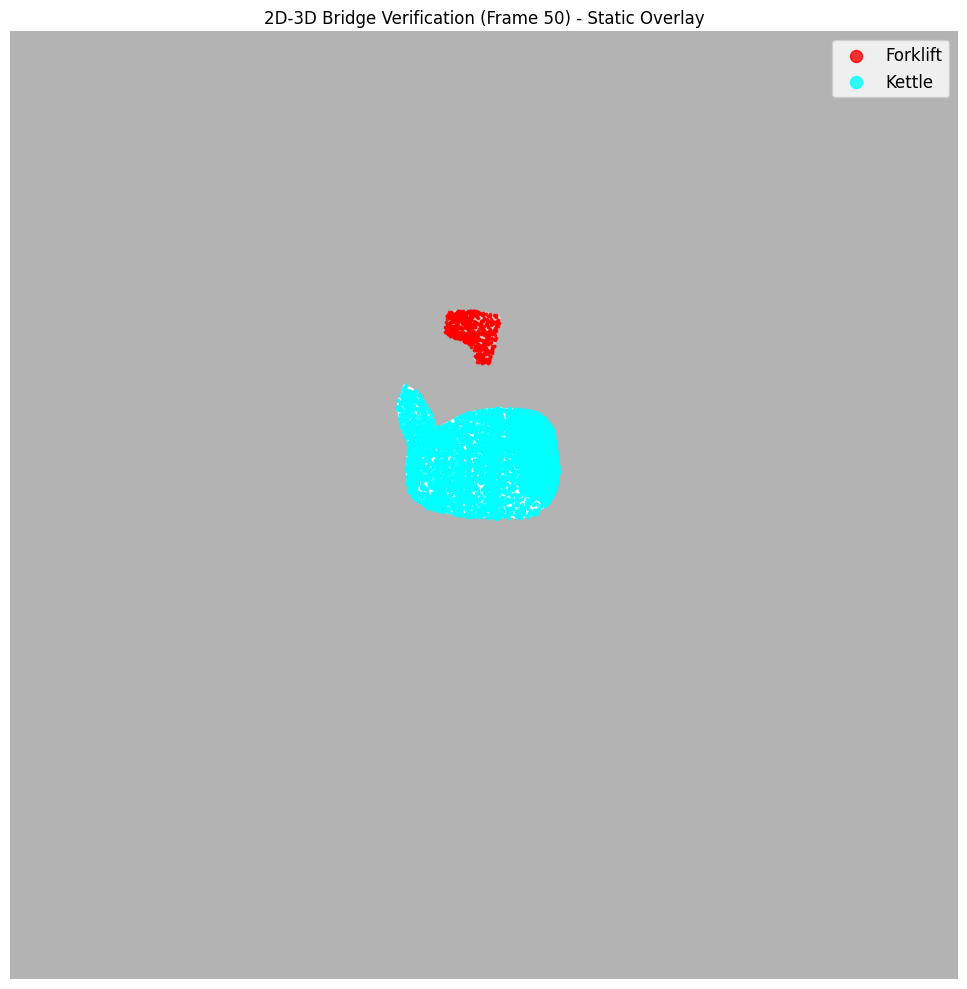

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_refined_verification(labeled_df, target_mask):
    """
    Overlays labeled points with a compact legend and fixed colors.
    """
    # Filter points belonging to objects
    target_pts = labeled_df[labeled_df['semantic_label'] > 0].copy()
    
    if target_pts.empty:
        print("No target points to visualize.")
        return

    # Identify the two main object IDs (excluding background 0)
    unique_ids = sorted(target_pts['semantic_label'].unique())
    print(f"Detected Object IDs in 3D: {unique_ids}")

    # Project points to image plane
    u_list, v_list, id_list = [], [], []
    for _, row in target_pts.iterrows():
        p_world = np.array([row['px_world'], row['py_world'], row['pz_world']])
        pix = project_world_to_rgb_image(p_world, row, rgb_calib, T_Device_Camera)
        if pix is not None:
            u_list.append(pix[0])
            v_list.append(pix[1])
            id_list.append(row['semantic_label'])

    # Convert to arrays for easier indexing
    u_list = np.array(u_list)
    v_list = np.array(v_list)
    id_list = np.array(id_list)

    plt.figure(figsize=(15, 10))
    plt.imshow(target_mask, cmap='gray', alpha=0.3)

    # Manual mapping for consistent colors:
    # We assign Red to the first ID (forklift) and Cyan to the second (kettle)
    colors_map = {unique_ids[0]: 'red', unique_ids[1]: 'cyan'} if len(unique_ids) >= 2 else {unique_ids[0]: 'red'}
    
    # Plot each object separately
    for obj_id, color in colors_map.items():
        mask_id = (id_list == obj_id)
        label_name = "Forklift" if color == 'red' else "Kettle"
        plt.scatter(u_list[mask_id], v_list[mask_id], c=color, s=3, alpha=0.8, label=label_name)
        
    plt.legend(loc='upper right', frameon=True, fontsize=12, markerscale=5)
    
    plt.title(f'2D-3D Bridge Verification (Frame {frame_idx}) - Static Overlay')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Run the refined verification
plot_refined_verification(labeled_points, mask)

### 7.4.2 Visualize in 3D
We will create a 3D scatter plot of the pointcloud, coloring points according to their assigned semantic labels to visually verify the segmentation results in 3D space.

In [9]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

def visualize_3d_zoomed(labeled_df, margin=1.5, bg_sample_frac=0.05):
    """
    Creates a 3D plot auto-focused on the labeled objects.
    """
    # Separate target objects and background
    target_pts = labeled_df[labeled_df['semantic_label'] > 0].copy()
    
    if target_pts.empty:
        print("No labeled points to focus on. Showing full cloud.")
        plot_df = labeled_df
        focus_box = None
    else:
        # Calculate Bounding Box of the target objects
        min_x, max_x = target_pts['px_world'].min(), target_pts['px_world'].max()
        min_y, max_y = target_pts['py_world'].min(), target_pts['py_world'].max()
        min_z, max_z = target_pts['pz_world'].min(), target_pts['pz_world'].max()
        
        # Filter background to show only points near the objects
        bg_pts = labeled_df[
            (labeled_df['semantic_label'] == 0) & 
            (labeled_df['px_world'] > min_x - margin) & (labeled_df['px_world'] < max_x + margin) &
            (labeled_df['py_world'] > min_y - margin) & (labeled_df['py_world'] < max_y + margin) &
            (labeled_df['pz_world'] > min_z - margin) & (labeled_df['pz_world'] < max_z + margin)
        ].sample(frac=bg_sample_frac, random_state=42)
        
        focus_box = {
            'x': [min_x - margin, max_x + margin],
            'y': [min_y - margin, max_y + margin],
            'z': [min_z - margin, max_z + margin]
        }

    fig = go.Figure()

    # Add Background (Context)
    fig.add_trace(go.Scatter3d(
        x=bg_pts['px_world'], y=bg_pts['py_world'], z=bg_pts['pz_world'],
        mode='markers',
        marker=dict(size=1.5, color='lightgray', opacity=0.4),
        name='Context (Near Objects)'
    ))

    # Add Target Objects
    unique_ids = sorted(target_pts['semantic_label'].unique())
    for i, obj_id in enumerate(unique_ids):
        obj_mask = target_pts['semantic_label'] == obj_id
        color = 'red' if i == 0 else 'cyan'
        name = 'Forklift' if color == 'red' else 'Kettle'
        
        fig.add_trace(go.Scatter3d(
            x=target_pts.loc[obj_mask, 'px_world'],
            y=target_pts.loc[obj_mask, 'py_world'],
            z=target_pts.loc[obj_mask, 'pz_world'],
            mode='markers',
            marker=dict(size=3, color=color, opacity=1.0),
            name=name
        ))

    # Set the camera and axes to focus only on the bounding box
    layout_dict = dict(
        title=f"3D Semantic Bridge (Zoomed View - Frame {frame_idx})",
        scene=dict(
            xaxis=dict(range=focus_box['x'], backgroundcolor="rgb(200, 200, 200)"),
            yaxis=dict(range=focus_box['y']),
            zaxis=dict(range=focus_box['z']),
            aspectmode='data'
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )
    
    fig.update_layout(layout_dict)
    fig.show()

# Run the zoomed visualization
visualize_3d_zoomed(labeled_points, margin=2.0, bg_sample_frac=0.1)